In [2]:
import pandas as pd
file_path = "/Users/yoonjoo/Desktop/cleaned_creditcard.csv"
df = pd.read_csv(file_path)
df_info = df.info()
df_head = df.head()
df_class_distribution = df["Class"].value_counts()

df_info, df_head, df_class_distribution

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 32 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Time        283726 non-null  float64
 1   V1          283726 non-null  float64
 2   V2          283726 non-null  float64
 3   V3          283726 non-null  float64
 4   V4          283726 non-null  float64
 5   V5          283726 non-null  float64
 6   V6          283726 non-null  float64
 7   V7          283726 non-null  float64
 8   V8          283726 non-null  float64
 9   V9          283726 non-null  float64
 10  V10         283726 non-null  float64
 11  V11         283726 non-null  float64
 12  V12         283726 non-null  float64
 13  V13         283726 non-null  float64
 14  V14         283726 non-null  float64
 15  V15         283726 non-null  float64
 16  V16         283726 non-null  float64
 17  V17         283726 non-null  float64
 18  V18         283726 non-null  float64
 19  V1

(None,
    Time        V1        V2        V3        V4        V5        V6        V7  \
 0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
 1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
 2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
 3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
 4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   
 
          V8        V9  ...       V22       V23       V24       V25       V26  \
 0  0.098698  0.363787  ...  0.277838 -0.110474  0.066928  0.128539 -0.189115   
 1  0.085102 -0.255425  ... -0.638672  0.101288 -0.339846  0.167170  0.125895   
 2  0.247676 -1.514654  ...  0.771679  0.909412 -0.689281 -0.327642 -0.139097   
 3  0.377436 -1.387024  ...  0.005274 -0.190321 -1.175575  0.647376 -0.221929   
 4 -0.270533  0.817739  ...  0.798278 -0.137458  0.141267 -0.206010  0.502292   
 
         V2

In [4]:
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, roc_curve, RocCurveDisplay
from collections import Counter
import matplotlib.pyplot as plt
import random

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
rng = np.random.RandomState(RANDOM_SEED)

file_path = "/Users/yoonjoo/Desktop/cleaned_creditcard.csv"
df = pd.read_csv(file_path)

if 'Class' not in df.columns:
    raise ValueError("Dataset must have a 'Class' column indicating fraud (1) or non-fraud (0).")

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

X_train_resampled = pd.DataFrame(X_train_resampled, columns=X.columns)

print("Class distribution AFTER SMOTE:", Counter(y_train_resampled))

fraud_indices = np.where(y_train_resampled == 1)[0] 

amount_col = 'Amount'
if amount_col in X_train_resampled.columns:
    noise = np.random.uniform(-0.05, 0.05, size=len(fraud_indices)) 
    X_train_resampled.loc[fraud_indices, amount_col] *= (1 + noise)

time_col = 'Time_Hours'
if time_col in X_train_resampled.columns:
    time_shift = np.random.randint(-2, 3, size=len(fraud_indices))
    X_train_resampled.loc[fraud_indices, time_col] += time_shift
    X_train_resampled[time_col] = X_train_resampled[time_col].clip(lower=0, upper=24) 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test) 

print("Mean of first few scaled features:", np.mean(X_train_scaled, axis=0))
print("Standard deviation of first few scaled features:", np.std(X_train_scaled, axis=0)[:5])

Class distribution AFTER SMOTE: Counter({0: 226602, 1: 226602})
Mean of first few scaled features: [ 6.69773119e-17  7.22451904e-17  3.51191898e-17 -3.91328115e-17
 -4.21430277e-17  1.75595949e-17 -1.11879705e-16  8.82996771e-17
 -1.25425678e-19  7.97707311e-17 -1.01343948e-16  3.66242979e-17
  0.00000000e+00  1.62543839e-17 -1.20408651e-17 -2.05698112e-17
  1.89643625e-16  5.81975145e-17  5.36821901e-17 -3.78785547e-17
  6.67264606e-17  4.76617575e-18  2.96004599e-17  1.17900137e-17
  1.90647030e-17  1.55998187e-18  2.19494936e-18  1.35459732e-17
  7.83910486e-18  3.71761709e-16 -2.19244085e-16]
Standard deviation of first few scaled features: [1. 1. 1. 1. 1.]


# Logistic Regression

In [39]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train_resampled)
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
print("\nLogistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_log):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_log):.4f}")


Logistic Regression Performance:
Accuracy: 0.9907
Precision: 0.1380
Recall: 0.8632
F1-score: 0.2380
AUC-ROC: 0.9637


In [10]:
import time

C_values = [0.01, 0.1, 1, 10, 100]

results = []

for c in C_values:
    log_reg = LogisticRegression(C=c, random_state=42, max_iter=1000)
    log_reg.fit(X_train_scaled, y_train_resampled)


    start_train = time.time()
    log_reg.fit(X_train_scaled, y_train_resampled)
    end_train = time.time()

    y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    thresholds = np.append(thresholds, 1)

    best_threshold = 0.5  # default
    for p, t in zip(precision, thresholds):
        if p >= 0.7:
            best_threshold = t
            break

    y_pred_adjusted = (y_prob >= best_threshold).astype(int)

    acc = accuracy_score(y_test, y_pred_adjusted)
    prec = precision_score(y_test, y_pred_adjusted)
    rec = recall_score(y_test, y_pred_adjusted)
    f1 = f1_score(y_test, y_pred_adjusted)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        'C': c,
        'Threshold': best_threshold,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'Accuracy': acc,
        'AUC-ROC': auc,
        'Train Time (s)': end_train - start_train
    })

results_df = pd.DataFrame(results)

print(results_df)

best_row = results_df.loc[results_df['AUC-ROC'].idxmax()]
best_c = best_row['C']

print(f"Best C based on AUC-ROC: {best_c}")
print(best_row)

        C  Threshold  Precision    Recall  F1-score  Accuracy   AUC-ROC  \
0    0.01   0.964815   0.700935  0.789474  0.742574  0.999084  0.966389   
1    0.10   0.974871   0.700935  0.789474  0.742574  0.999084  0.964473   
2    1.00   0.983868   0.700935  0.789474  0.742574  0.999084  0.963702   
3   10.00   0.984940   0.700935  0.789474  0.742574  0.999084  0.963589   
4  100.00   0.984907   0.700935  0.789474  0.742574  0.999084  0.963576   

   Train Time (s)  
0        0.631808  
1        0.847617  
2        0.874448  
3        0.826061  
4        0.781552  
Best C based on AUC-ROC: 0.01
C                 0.010000
Threshold         0.964815
Precision         0.700935
Recall            0.789474
F1-score          0.742574
Accuracy          0.999084
AUC-ROC           0.966389
Train Time (s)    0.631808
Name: 0, dtype: float64


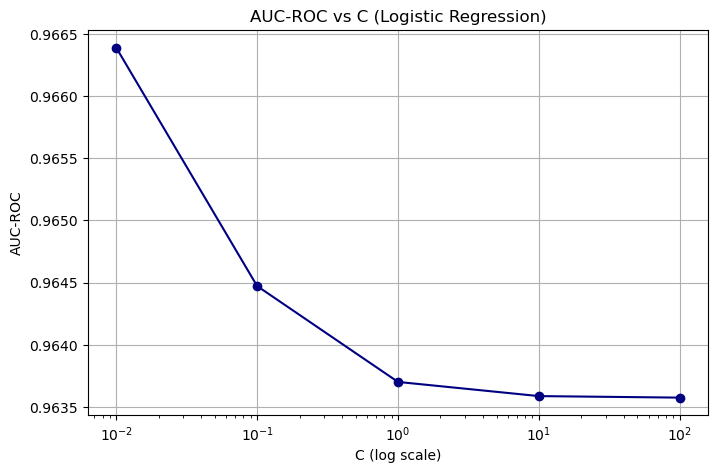

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Line Plot: AUC-ROC vs C (log scale)
plt.figure(figsize=(8,5))
plt.plot(results_df['C'], results_df['AUC-ROC'], marker='o', linestyle='-', color='navy')
plt.xscale('log')
plt.title('AUC-ROC vs C (Logistic Regression)')
plt.xlabel('C (log scale)')
plt.ylabel('AUC-ROC')
plt.grid(True)
plt.show()

Top 10 features by absolute coefficient:


,feature,coefficient,importance
0,V14,-4.922105,4.922105
1,V12,-4.309169,4.309169
2,V10,-2.940701,2.940701
3,V4,2.609955,2.609955
4,V17,-2.552145,2.552145
5,V8,-1.844345,1.844345
6,V11,1.238112,1.238112
7,V3,-1.190859,1.190859
8,V1,1.183508,1.183508
9,V16,-1.071091,1.071091


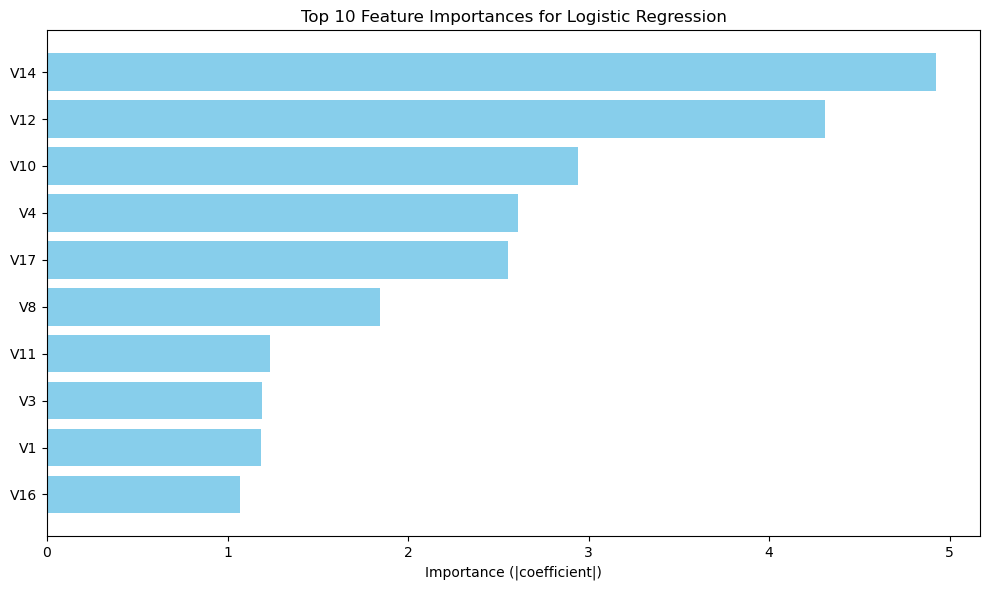

In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Retrain the best Logistic Regression on the full resampled training set
best_row = results_df.loc[results_df['AUC-ROC'].idxmax()]
best_c = best_row['C']

best_model = LogisticRegression(C=best_c, random_state=42, max_iter=1000)
best_model.fit(X_train_scaled, y_train_resampled)

# Extract feature names and coefficients
feature_names = X_train.columns.tolist()           # e.g. ['v1', 'v2', ..., 'v28']
coefficients  = best_model.coef_.flatten()         # shape (n_features,)

# Compute absolute importance
importance = np.abs(coefficients)

# Build a DataFrame of importances
feat_imp_df = pd.DataFrame({
    'feature':     feature_names,
    'coefficient': coefficients,
    'importance':  importance
})

# Sort by importance descending
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

# Display top 10 features
print("Top 10 features by absolute coefficient:")
display(feat_imp_df.head(10))

# Plot the top 10 feature importances
plt.figure(figsize=(10, 6))
plt.barh(
    feat_imp_df['feature'].head(10)[::-1],
    feat_imp_df['importance'].head(10)[::-1],
    color='skyblue'
)
plt.xlabel('Importance (|coefficient|)')
plt.title('Top 10 Feature Importances for Logistic Regression')
plt.tight_layout()
plt.show()

In [8]:
import time

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled_orig = scaler.fit_transform(X_train)
X_test_scaled_orig  = scaler.transform(X_test)

best_c = 0.01
model_orig = LogisticRegression(C=best_c, random_state=42, max_iter=1000)

start_train = time.time()
model_orig.fit(X_train_scaled_orig, y_train)
train_time = time.time() - start_train

y_prob = model_orig.predict_proba(X_test_scaled_orig)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
thresholds = np.append(thresholds, 1.0)
f1_arr = 2 * (precision * recall) / (precision + recall + 1e-8)

mask = precision >= 0.7
if mask.any():
    idxs = np.where(mask)[0]
    best_idx = idxs[np.argmax(f1_arr[mask])]
else:
    best_idx = np.argmax(f1_arr)
best_thresh = thresholds[best_idx]

y_pred = (y_prob >= best_thresh).astype(int)

print("Logistic Regression on Original Data (no imbalance handling):")
print(f"Accuracy:          {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision:         {precision_score(y_test, y_pred):.4f}")
print(f"Recall:            {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:          {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:           {roc_auc_score(y_test, y_prob):.4f}")
print(f"Optimal Threshold: {best_thresh:.4f}")
print(f"Training Time:     {train_time:.4f} s")

Logistic Regression on Original Data (no imbalance handling):
Accuracy:          0.9993
Precision:         0.8276
Recall:            0.7579
F1-score:          0.7912
AUC-ROC:           0.9577
Optimal Threshold: 0.0671
Training Time:     0.1613 s


# Random Forest

In [14]:
rf = RandomForestClassifier(random_state=42, max_depth=10, n_estimators=100)
rf.fit(X_train_scaled, y_train_resampled)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
print("\nRandom Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")


Random Forest Performance:
Accuracy: 0.9986
Precision: 0.5455
Recall: 0.8211
F1-score: 0.6555
AUC-ROC: 0.9666


In [16]:
import time
import numpy as np
import pandas as pd
from xgboost import XGBRFClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)
from IPython.display import display

# Original F1 baseline
orig_f1 = 0.6555

# Hyperparameter grid
max_depth_list    = [10, 30, 50]
n_estimators_list = [100, 300, 500]

records = []

for depth in max_depth_list:
    for n_est in n_estimators_list:
        clf = XGBRFClassifier(
            max_depth=depth,
            n_estimators=n_est,
            random_state=42,
            n_jobs=-1
        )
        
        # measure training time
        start_train = time.time()
        clf.fit(X_train_scaled, y_train_resampled)
        train_time = time.time() - start_train
        
        # predictions
        y_pred = clf.predict(X_test_scaled)
        y_prob = clf.predict_proba(X_test_scaled)[:,1]
        
        # compute metrics
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred)
        auc  = roc_auc_score(y_test, y_prob)
        
        # store only those with F1 > baseline
        if f1 > orig_f1:
            records.append({
                'max_depth':    depth,
                'n_estimators': n_est,
                'Train Time (s)': train_time,
                'Accuracy':     acc,
                'Precision':    prec,
                'Recall':       rec,
                'F1-score':     f1,
                'AUC-ROC':      auc
            })

# assemble DataFrame
candidates = pd.DataFrame(records).sort_values(['F1-score','Recall'], ascending=False)

if not candidates.empty:
    print("Combinations with F1-score > 0.6555:")
    display(candidates)
    
    # pick the one with highest Recall
    best = candidates.loc[candidates['Recall'].idxmax()]
    print("\nBest combination (highest Recall among those):")
    print(f"max_depth = {int(best['max_depth'])}, n_estimators = {int(best['n_estimators'])}")
    print(f"  Train Time: {best['Train Time (s)']:.4f} s")
    print(f"  Accuracy  : {best['Accuracy']:.4f}")
    print(f"  Precision : {best['Precision']:.4f}")
    print(f"  Recall    : {best['Recall']:.4f}")
    print(f"  F1-score  : {best['F1-score']:.4f}")
    print(f"  AUC-ROC   : {best['AUC-ROC']:.4f}")
else:
    print("No parameter combination achieves F1-score > 0.6555.")

Combinations with F1-score > 0.6555:


,max_depth,n_estimators,Train Time (s),Accuracy,Precision,Recall,F1-score,AUC-ROC
5,50,500,15.967426,0.999383,0.833333,0.789474,0.810811,0.935608
3,50,100,3.287141,0.999366,0.824176,0.789474,0.806452,0.900864
0,30,100,3.148709,0.999366,0.831461,0.778947,0.804348,0.898857
4,50,300,9.266619,0.999348,0.815217,0.789474,0.802139,0.938841
2,30,500,15.214807,0.999348,0.822222,0.778947,0.800000,0.927677
1,30,300,9.009410,0.999330,0.813187,0.778947,0.795699,0.914412



Best combination (highest Recall among those):
max_depth = 50, n_estimators = 500
  Train Time: 15.9674 s
  Accuracy  : 0.9994
  Precision : 0.8333
  Recall    : 0.7895
  F1-score  : 0.8108
  AUC-ROC   : 0.9356


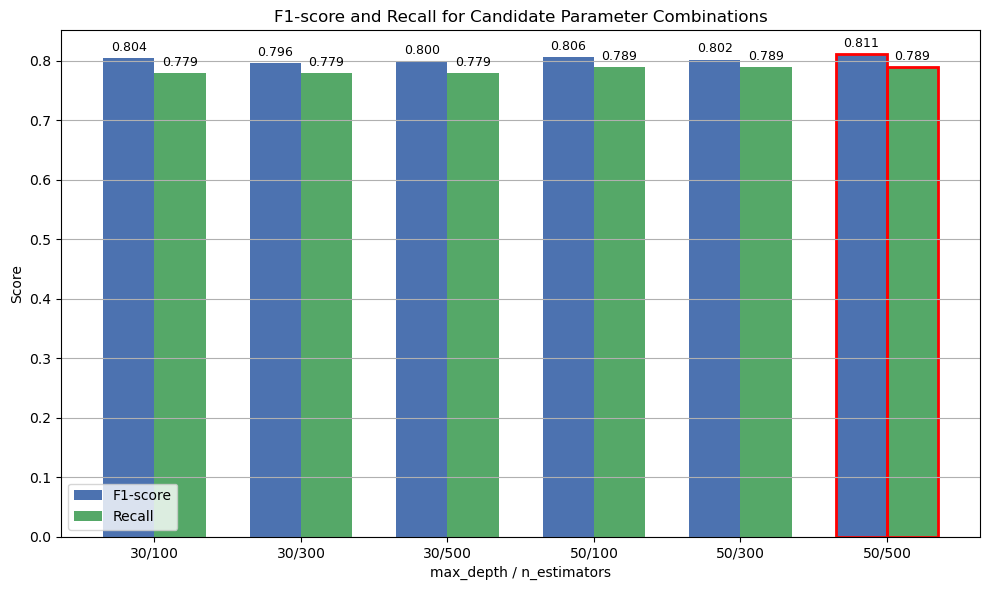

In [23]:
# Sort ascending by max_depth then n_estimators
candidates_sorted = candidates.sort_values(['max_depth','n_estimators']).reset_index(drop=True)
candidates_sorted['combo'] = (
    candidates_sorted['max_depth'].astype(int).astype(str)
    + '/' +
    candidates_sorted['n_estimators'].astype(int).astype(str)
)

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(candidates_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plot F1 and Recall bars
rects_f1 = ax.bar(x - width/2, 
                  candidates_sorted['F1-score'], 
                  width, label='F1-score', color='#4C72B0')
rects_rec = ax.bar(x + width/2, 
                   candidates_sorted['Recall'], 
                   width, label='Recall', color='#55A868')

# Tie-break to get the correct best index
max_rec = candidates_sorted['Recall'].max()
rec_tied = candidates_sorted[candidates_sorted['Recall'] == max_rec]
best_combo = rec_tied.loc[rec_tied['F1-score'].idxmax()]
best_idx = candidates_sorted[
    (candidates_sorted['max_depth'] == best_combo['max_depth']) &
    (candidates_sorted['n_estimators'] == best_combo['n_estimators'])
].index[0]

# Highlight that correct bar
ax.bar(x[best_idx] - width/2,
       candidates_sorted.loc[best_idx, 'F1-score'],
       width, fill=False, edgecolor='red', linewidth=2)
ax.bar(x[best_idx] + width/2,
       candidates_sorted.loc[best_idx, 'Recall'],
       width, fill=False, edgecolor='red', linewidth=2)

# Annotate bar values
def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)
autolabel(rects_f1)
autolabel(rects_rec)

# Final formatting
ax.set_xticks(x)
ax.set_xticklabels(candidates_sorted['combo'])
ax.set_xlabel('max_depth / n_estimators')
ax.set_ylabel('Score')
ax.set_title('F1-score and Recall for Candidate Parameter Combinations')
ax.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

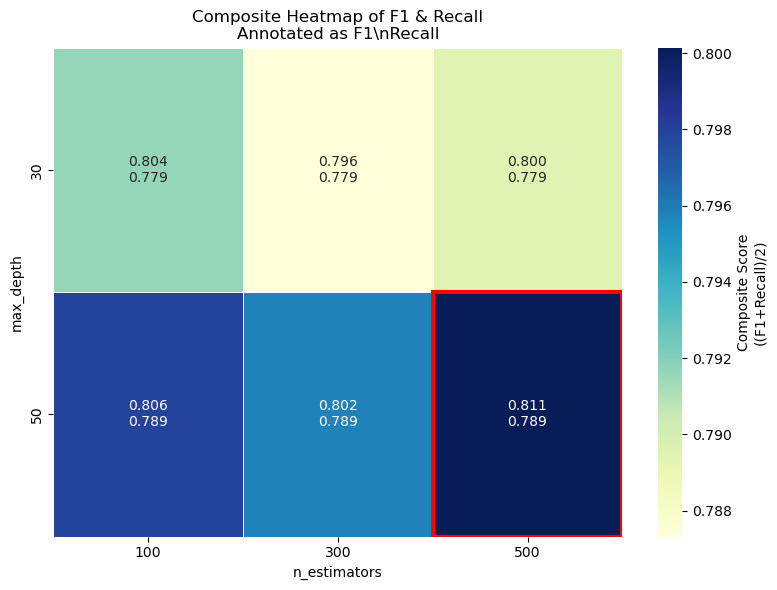

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Re-create the 'candidates' DataFrame
candidates = pd.DataFrame([
    {'max_depth':50,'n_estimators':500,'Recall':0.789474,'F1-score':0.810811},
    {'max_depth':50,'n_estimators':100,'Recall':0.789474,'F1-score':0.806452},
    {'max_depth':30,'n_estimators':100,'Recall':0.778947,'F1-score':0.804348},
    {'max_depth':50,'n_estimators':300,'Recall':0.789474,'F1-score':0.802139},
    {'max_depth':30,'n_estimators':500,'Recall':0.778947,'F1-score':0.800000},
    {'max_depth':30,'n_estimators':300,'Recall':0.778947,'F1-score':0.795699},
])

# Step 1: compute composite score
candidates['Composite'] = (candidates['F1-score'] + candidates['Recall']) / 2

# Step 2: pivot for heatmap
heatmap_data = candidates.pivot(
    index='max_depth',
    columns='n_estimators',
    values='Composite'
).sort_index(axis=1)

# Step 3: identify best cell
best = candidates.loc[candidates['Composite'].idxmax()]
best_depth, best_n = int(best['max_depth']), int(best['n_estimators'])

# Step 4: build annotation DataFrame
annot = heatmap_data.copy().astype(str)
annot[:] = ''
for _, row in candidates.iterrows():
    d, n = int(row['max_depth']), int(row['n_estimators'])
    annot.at[d, n] = f"{row['F1-score']:.3f}\n{row['Recall']:.3f}"

# Step 5: plot heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    heatmap_data,
    annot=annot,
    fmt='',
    cmap='YlGnBu',
    cbar_kws={'label': 'Composite Score\n((F1+Recall)/2)'},
    linewidths=0.5,
    linecolor='white'
)

# Step 6: outline best cell
depths = list(heatmap_data.index)
ests   = list(heatmap_data.columns)
i = depths.index(best_depth)
j = ests.index(best_n)
ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', lw=3))

# Final formatting
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
ax.set_title('Composite Heatmap of F1 & Recall\nAnnotated as F1\\nRecall')
plt.tight_layout()
plt.show()

Top 10 Features by Importance:


,feature,importance
0,V14,0.655781
1,V10,0.133737
2,V12,0.059066
3,V4,0.025873
4,V17,0.024186
5,V11,0.006245
6,V22,0.005139
7,V3,0.005060
8,V9,0.004901
9,V18,0.004784


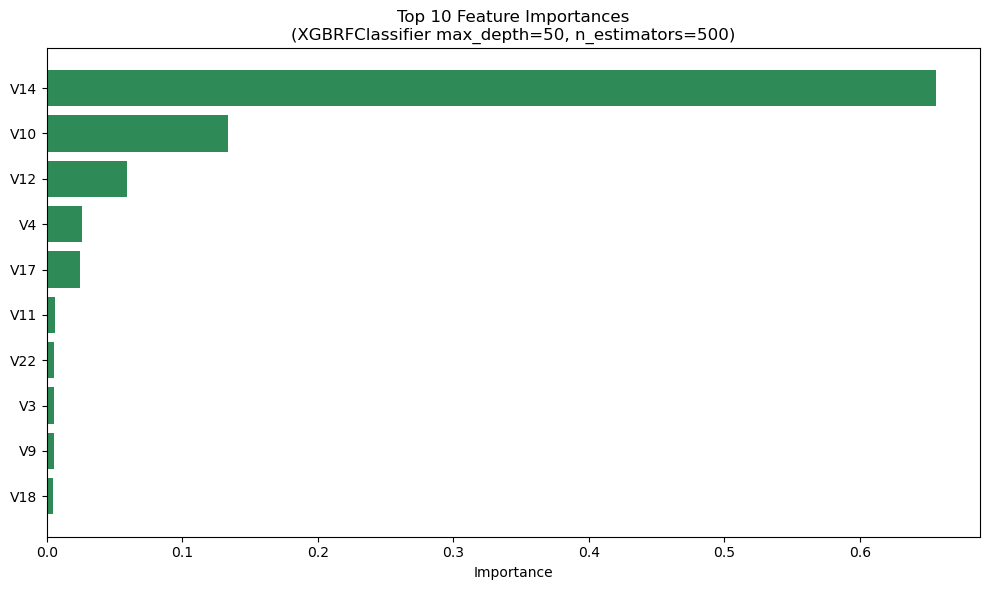

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

clf_best = clf 

# Extract importances
feature_names = X.columns.tolist()           # ['v1','v2',...,'v28']
importances   = clf_best.feature_importances_

# Build and sort DataFrame
feat_imp = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Display top 10
print("Top 10 Features by Importance:")
display(feat_imp.head(10))

# Plot
plt.figure(figsize=(10,6))
plt.barh(
    feat_imp['feature'].head(10)[::-1],
    feat_imp['importance'].head(10)[::-1],
    color='seagreen'
)
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances\n(XGBRFClassifier max_depth=50, n_estimators=500)')
plt.tight_layout()
plt.show()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled_orig = scaler.fit_transform(X_train)
X_test_scaled_orig  = scaler.transform(X_test)

best_depth = 50
best_n_est = 500

xgb_rf_orig = XGBRFClassifier(
    max_depth=best_depth,
    n_estimators=best_n_est,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

start_train = time.time()
xgb_rf_orig.fit(X_train_scaled_orig, y_train)
train_time = time.time() - start_train

y_pred = xgb_rf_orig.predict(X_test_scaled_orig)
y_prob = xgb_rf_orig.predict_proba(X_test_scaled_orig)[:,1]

print("XGBRFClassifier on Original Data (no imbalance handling):")
print(f"Accuracy     : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision    : {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall       : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score     : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC      : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Training Time: {train_time:.4f} s")

XGBRFClassifier on Original Data (no imbalance handling):
Accuracy     : 0.9994
Precision    : 0.8889
Recall       : 0.7579
F1-score     : 0.8182
AUC-ROC      : 0.9535
Training Time: 4.7750 s
